In [1]:
import torch
import torch.nn as nn
import json
import gym
import gym_cityflow
import cityflow
import os
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim
from torch_geometric.nn import GATConv
from torch_geometric.utils import add_self_loops

In [2]:
class DuelingGAT(torch.nn.Module):
    def __init__(
        self,
        in_dim: int,      
        hidden_dim: int,  
        action_dim: int, 
        heads: int = 4 
    ):
        super().__init__()
        self.gat1 = GATConv(in_dim, hidden_dim, heads=heads, concat=True)
        self.gat2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, concat=False)

        self.val_fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim // 2, 1)
        )
        
        self.adv_fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim // 2, action_dim)
        )

    def forward(self, x: torch.Tensor, edge_index: torch.LongTensor):
        h = F.elu(self.gat1(x, edge_index))
        h = F.elu(self.gat2(h, edge_index))
        V = self.val_fc(h)                        
        A = self.adv_fc(h)                        
        Q = V + (A - A.mean(dim=1, keepdim=True)) 

        return Q


In [3]:

cfg = json.load(open("Intersections_4/sample_config.json", "r"))
roadnet = json.load(open(cfg["dir"] + cfg["roadnetFile"], "r"))

intersections = [
    inter["id"]
    for inter in roadnet["intersections"]
    if not inter.get("virtual", False)
]
intersections = sorted(intersections)
node_to_idx = {node: idx for idx, node in enumerate(intersections)}

edges = []
for road in roadnet["roads"]:
    u = road.get("startIntersection")
    v = road.get("endIntersection")
    if u in node_to_idx and v in node_to_idx:
        ui, vi = node_to_idx[u], node_to_idx[v]
        edges.append([ui, vi])
        edges.append([vi, ui])   


edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
edge_index, _ = add_self_loops(edge_index, num_nodes=len(intersections))


print("Node mapping (intersection_id → node_idx):")
for inter, idx in node_to_idx.items():
    print(f"  {inter} → {idx}")

print("\nEdge index tensor:")
print(edge_index)


Node mapping (intersection_id → node_idx):
  intersection_1_1 → 0
  intersection_1_2 → 1
  intersection_1_3 → 2
  intersection_1_4 → 3
  intersection_2_1 → 4
  intersection_2_2 → 5
  intersection_2_3 → 6
  intersection_2_4 → 7
  intersection_3_1 → 8
  intersection_3_2 → 9
  intersection_3_3 → 10
  intersection_3_4 → 11
  intersection_4_1 → 12
  intersection_4_2 → 13
  intersection_4_3 → 14
  intersection_4_4 → 15

Edge index tensor:
tensor([[ 0,  4,  0,  1,  1,  5,  1,  2,  1,  0,  2,  6,  2,  3,  2,  1,  3,  7,
          3,  2,  4,  8,  4,  5,  4,  0,  5,  9,  5,  6,  5,  1,  5,  4,  6, 10,
          6,  7,  6,  2,  6,  5,  7, 11,  7,  3,  7,  6,  8, 12,  8,  9,  8,  4,
          9, 13,  9, 10,  9,  5,  9,  8, 10, 14, 10, 11, 10,  6, 10,  9, 11, 15,
         11,  7, 11, 10, 12, 13, 12,  8, 13, 14, 13,  9, 13, 12, 14, 15, 14, 10,
         14, 13, 15, 11, 15, 14,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11,
         12, 13, 14, 15],
        [ 4,  0,  1,  0,  5,  1,  2,  1,  0,  1,  6

In [4]:
class PrioritizedReplayBuffer:
    def __init__(self, max_size, num_agents, obs_dim, alpha=0.6, eps=1e-6):
        self.max_size = max_size
        self.num_agents = num_agents
        self.obs_dim = obs_dim
        self.alpha = alpha
        self.eps = eps
        self.pos = 0
        self.size = 0
        self.states      = np.zeros((max_size, num_agents, obs_dim), dtype=np.float32)
        self.next_states = np.zeros((max_size, num_agents, obs_dim), dtype=np.float32)
        self.actions     = np.zeros((max_size, num_agents), dtype=np.int64)
        self.rewards     = np.zeros((max_size, num_agents), dtype=np.float32)
        self.dones       = np.zeros(max_size, dtype=np.float32)
        self.priorities  = np.zeros(max_size, dtype=np.float32)

    def store(self, states, actions, next_states, rewards, done):
        self.states[self.pos]      = states
        self.next_states[self.pos] = next_states
        self.actions[self.pos]     = actions
        self.rewards[self.pos]     = rewards
        self.dones[self.pos]       = float(done)
        
        max_prio = self.priorities.max() if self.size > 0 else 1.0
        self.priorities[self.pos] = max_prio
        self.pos = (self.pos + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batch_size, beta=0.4):
        if self.size == self.max_size:
            prios = self.priorities
        else:
            prios = self.priorities[:self.size]

        probs = prios ** self.alpha
        probs /= probs.sum()
        idxs = np.random.choice(len(probs), batch_size, p=probs)
        total   = len(probs)
        weights = (total * probs[idxs]) ** (-beta)
        weights /= weights.max()  
        states, actions = self.states[idxs], self.actions[idxs]
        rewards, next_states = self.rewards[idxs], self.next_states[idxs]
        dones = self.dones[idxs]

        return states, actions, rewards, next_states, dones, idxs, weights

    def update_priorities(self, idxs, td_errors):
        for i, e in zip(idxs, td_errors):
            self.priorities[i] = abs(e) + self.eps

    def __len__(self):
        return self.size


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
edge_index = edge_index.to(device)

In [6]:
class DQNAgentManager:
    def __init__(
        self, obs_dim, action_dim, num_agents,
        buffer_size=8000, batch_size=128,
        train_freq=4, target_update_freq=8,
        lr=1e-4, gamma=0.85,
        epsilon_start=1.0, epsilon_min=0.25,
        epsilon_decay=None,
        reward_norm_momentum=1e-3, reward_norm_eps=1e-8,
        max_grad_norm=1.0
    ):
        self.obs_dim  = obs_dim
        self.action_dim = action_dim
        self.num_agents = num_agents
        self.batch_size = batch_size
        self.train_freq = train_freq
        self.target_update_freq = target_update_freq
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.r_mean     = 0.0
        self.r_var      = 1.0
        self.r_momentum = reward_norm_momentum
        self.r_eps      = reward_norm_eps
        self.max_grad_norm = max_grad_norm

        self.q_net = DuelingGAT(obs_dim, hidden_dim=64, action_dim=action_dim, heads=4).to(device)
        self.target_net = DuelingGAT(obs_dim, hidden_dim=64, action_dim=action_dim, heads=4).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.replay_buffer = PrioritizedReplayBuffer(max_size=buffer_size, num_agents=num_agents, obs_dim=obs_dim, alpha=0.6)

        self.step_count = 0

    def select_actions(self, obs_batch):
        
        x = torch.tensor(obs_batch, dtype=torch.float32, device=device)  
        with torch.no_grad():
            qv = self.q_net(x, edge_index)  
        actions = []
        for i in range(self.num_agents):
            if np.random.rand() < self.epsilon:
                actions.append(np.random.randint(self.action_dim))
            else:
                actions.append(int(qv[i].argmax().item()))
        return actions

    def store_transition(self, states, actions, next_states, rewards, done):
        
        raw = np.array(rewards, dtype=np.float32).flatten()
        m, v = raw.mean(), raw.var()
        delta = m - self.r_mean
        self.r_mean += self.r_momentum * delta
        self.r_var  += self.r_momentum * (v - self.r_var)

        normed = (raw - self.r_mean) / (np.sqrt(self.r_var) + self.r_eps)
        normed = normed.reshape(len(rewards))
        self.replay_buffer.store(states, actions, next_states, normed, done)

    def step(self):
        self.step_count += 1
        if len(self.replay_buffer) >= self.batch_size and self.step_count % self.train_freq == 0:
            self._learn()
        if self.step_count % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

    def end_episode(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def _learn(self, beta=0.4):
        (states, actions, rewards, next_states, dones, idxs, weights) = \
            self.replay_buffer.sample(self.batch_size, beta=beta)
        bs, na, od = states.shape

        
        s  = torch.FloatTensor(states.reshape(bs*na, od)).to(device)
        a  = torch.LongTensor(actions.reshape(bs*na, 1)).to(device)
        r  = torch.FloatTensor(rewards.reshape(bs*na, 1)).to(device)
        s2 = torch.FloatTensor(next_states.reshape(bs*na, od)).to(device)
        d  = torch.FloatTensor(dones.repeat(na).reshape(bs*na, 1)).to(device)
        w  = torch.FloatTensor(weights.repeat(na).reshape(bs*na,1)).to(device)

        
        q_vals = self.q_net(s, edge_index).gather(1, a)

        with torch.no_grad():
            q_next = self.target_net(s2, edge_index).max(1, keepdim=True)[0]
            target = r + self.gamma * q_next * (1 - d)

        td_errors = (target - q_vals).detach().cpu().numpy().flatten()
        loss = (w * (q_vals - target).pow(2)).mean()

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), self.max_grad_norm)
        self.optimizer.step()

        self.replay_buffer.update_priorities(idxs, td_errors)


In [7]:
def train_multi_dqn(
    config_path, num_agents=16, obs_dim=72, action_dim=9,
    num_episodes=500, max_steps_per_episode=1000,
    buffer_size=10000, batch_size=128, train_freq=4, target_update_freq=8,
    gamma=0.85, lr=1e-4, epsilon_start=1.0, epsilon_min=0.25,
    checkpoint_interval=250, checkpoint_dir="checkpoints"
):
    os.makedirs(checkpoint_dir, exist_ok=True)
    env = gym.make(id='cityflow-v0', configPath=config_path,
                   episodeSteps=max_steps_per_episode)
    raw_obs = env.reset()
    intersection_ids = sorted(raw_obs.keys())

    epsilon_decay = (epsilon_min/epsilon_start)**(1.0/num_episodes)
    beta_start, beta_end = 0.2, 1.0

    agent_mgr = DQNAgentManager(
        obs_dim=obs_dim, action_dim=action_dim, num_agents=num_agents,
        buffer_size=buffer_size, batch_size=batch_size,
        train_freq=train_freq, target_update_freq=target_update_freq,
        lr=lr, gamma=gamma,
        epsilon_start=epsilon_start, epsilon_min=epsilon_min,
        epsilon_decay=epsilon_decay
    )

    rewards_history = []
    for ep in range(1, num_episodes+1):
        seed_val = np.random.randint(0, 1_000_000)
        env.seed(seed_val)
        raw_obs = env.reset()
        obs = [np.array(raw_obs[k], dtype=np.float32).flatten()
               for k in intersection_ids]
        total_reward = 0
        beta = beta_start + (beta_end - beta_start) * (ep / num_episodes)
        for t in range(max_steps_per_episode):
            actions = agent_mgr.select_actions(obs)
            next_raw_obs, rewards, done, _ = env.step(actions)
            next_obs = [np.array(next_raw_obs[k], dtype=np.float32).flatten()
                        for k in intersection_ids]

            reward_dict  = {k:v for k,v in rewards}
            rewards_list = [reward_dict[k] for k in intersection_ids]
            total_reward += sum(rewards_list)

            agent_mgr.store_transition(obs, actions, next_obs, rewards_list, done)
            agent_mgr.step_count += 1
            if len(agent_mgr.replay_buffer) >= batch_size and agent_mgr.step_count % train_freq == 0:
                agent_mgr._learn(beta=beta)

            if agent_mgr.step_count % target_update_freq == 0:
                agent_mgr.target_net.load_state_dict(agent_mgr.q_net.state_dict())

            obs = next_obs
            if done:
                break

        agent_mgr.end_episode()
        rewards_history.append(total_reward)
        print(f"Episode {ep:4d} | Steps {t:3d} | "
              f"Reward {total_reward:.1f} | ε {agent_mgr.epsilon:.3f} | β {beta:.3f}")

        if ep % checkpoint_interval == 0:
            torch.save(agent_mgr.q_net.state_dict(),
                       os.path.join(checkpoint_dir, f"qnet_gat__per_ep{ep}.pth"))

    
    torch.save(agent_mgr.q_net.state_dict(),
               os.path.join(checkpoint_dir, "qnet_final_per_gat.pth"))
    plt.plot(rewards_history)
    plt.xlabel("Episode"); plt.ylabel("Total Reward")
    plt.title("Multi-Agent Dueling GAT-DQN")
    plt.show()


/user/gaganvad/.local/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:174: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.warn(
/user/gaganvad/.local/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:187: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.warn(
/user/gaganvad/.local/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `<class 'dict'>`
  logger.warn(
/scratch/19534219/ipykernel_122102/1992767655.py:47: UserWarning: Creating a tensor from a list of numpy.ndarrays is extrem

Episode    1 | Steps 998 | Reward -963623.4 | ε 0.997 | β 0.202
Episode    2 | Steps 998 | Reward -954889.8 | ε 0.994 | β 0.203
Episode    3 | Steps 998 | Reward -945603.0 | ε 0.992 | β 0.205
Episode    4 | Steps 998 | Reward -980458.2 | ε 0.989 | β 0.206
Episode    5 | Steps 998 | Reward -944045.4 | ε 0.986 | β 0.208
Episode    6 | Steps 998 | Reward -935421.0 | ε 0.984 | β 0.210
Episode    7 | Steps 998 | Reward -936658.2 | ε 0.981 | β 0.211
Episode    8 | Steps 998 | Reward -854460.6 | ε 0.978 | β 0.213
Episode    9 | Steps 998 | Reward -865893.6 | ε 0.975 | β 0.214
Episode   10 | Steps 998 | Reward -874324.8 | ε 0.973 | β 0.216
Episode   11 | Steps 998 | Reward -892862.4 | ε 0.970 | β 0.218
Episode   12 | Steps 998 | Reward -890707.2 | ε 0.967 | β 0.219
Episode   13 | Steps 998 | Reward -830235.6 | ε 0.965 | β 0.221
Episode   14 | Steps 998 | Reward -897521.4 | ε 0.962 | β 0.222
Episode   15 | Steps 998 | Reward -841208.4 | ε 0.959 | β 0.224
Episode   16 | Steps 998 | Reward -88451

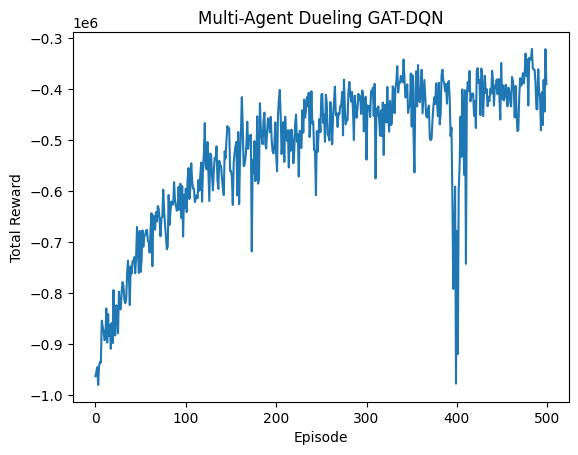

In [8]:
train_multi_dqn("Intersections_4/sample_config.json")